# <b><font color='teal'>Практикум 12</font></b>

### <font color='teal'>Описание данных</font>

##### <font color='teal'>Таблицы uber_cab_rides, lyft_car_rides</font>
- distance - расстояние поездки в милях
- cab_type - Lyft/Uber
- timestamp - время, когда были собраны данные в формте Unix timestamp
- destination - пункт назначения
- source - пункт отправления
- price - цена поездки в долларах США
- surge_multiplier - множитель динамического ценообразования
- id - уникальный идентификатор поездки
- product_id -идентификатор категории такси
- name - название категории такси

##### <font color='teal'>Таблица weather</font>
- temp - температура в градусах фаренгейта
- location - географическое местоположение
- timestamp - время, когда были собраны данные в формте Unix timestamp
- clouds - облачность от 0 до 1
- pressure - атомсферное давление в миллибарах
- rain - количество осадков за последний час в дюймах
- timestamp - время, когда были собраны данные (Unix timestamp)
- humidity - влажность в процентах
- wind - скорость ветра в милях в час (MPH)

### <font color='teal'>Задача №1</font>

Загрузите данные в DataFrames polars: df_uber_rides, df_lyft_rides, df_weather
- При загрузке данных измените тип данных с timestamp на привычный datetime с помощью конструкции with_columns(pl.from_epoch(pl.col("time_stamp"), time_unit="ms")

In [26]:
import polars as pl
from datetime import timedelta
df_uber_rides = pl.read_csv("../data/uber_cab_rides.csv").with_columns(pl.from_epoch(pl.col("time_stamp"), time_unit="ms")).sort("time_stamp")
display(df_uber_rides.head())
df_lyft_rides = pl.read_csv("../data/lyft_cab_rides.csv").with_columns(pl.from_epoch(pl.col("time_stamp"), time_unit="ms")).sort("time_stamp")
display(df_lyft_rides.head())
df_weather = pl.read_csv("../data/weather.csv").with_columns(pl.from_epoch(pl.col("time_stamp"), time_unit="s")).sort("time_stamp")
display(df_weather.head())

distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str
1.3,"""Uber""",2018-11-26 03:40:46.319,"""Theatre District""","""South Station""",18.5,1.0,"""00ea74ea-2c49-416c-bfc5-f78770вЂ¦","""6c84fd89-3f11-4782-9b50-97c468вЂ¦","""Black"""
1.57,"""Uber""",2018-11-26 03:40:46.319,"""North End""","""Theatre District""",null,1.0,"""9962f244-8fce-4ae9-a583-139d5dвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi"""
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",null,1.0,"""2ee597c2-b685-450e-b3a2-2df42fвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi"""
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",32.0,1.0,"""6172077a-22de-481b-aae2-b5763cвЂ¦","""6f72dfc5-27f1-42e8-84db-ccc7a7вЂ¦","""UberXL"""
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",19.5,1.0,"""8682f9bf-5cc0-4dfc-b8fe-4e2207вЂ¦","""55c66225-fbe7-4fd5-9072-eab1ecвЂ¦","""UberX"""


distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str
3.03,"""Lyft""",2018-11-26 03:40:46.318,"""Theatre District""","""Boston University""",34.0,1.0,"""ef4771c2-c88d-4730-aaf7-a95751вЂ¦","""lyft_luxsuv""","""Lux Black XL"""
2.43,"""Lyft""",2018-11-26 03:40:46.320,"""Beacon Hill""","""Northeastern University""",10.5,1.0,"""edfc7f44-97e1-48cd-930c-e4fe20вЂ¦","""lyft""","""Lyft"""
2.22,"""Lyft""",2018-11-26 03:40:46.359,"""Northeastern University""","""Theatre District""",7.0,1.0,"""9f82af6e-e67f-452a-8d63-f860cbвЂ¦","""lyft_line""","""Shared"""
4.46,"""Lyft""",2018-11-26 03:40:46.359,"""Financial District""","""Boston University""",62.5,1.75,"""1178f52c-9bd4-4b28-a03a-d94e68вЂ¦","""lyft_lux""","""Lux Black"""
4.46,"""Lyft""",2018-11-26 03:40:46.359,"""Financial District""","""Boston University""",47.5,1.75,"""3b5af7f6-40ba-42f2-a218-971dcbвЂ¦","""lyft_premier""","""Lux"""


temp,location,clouds,pressure,rain,time_stamp,humidity,wind
f64,str,f64,f64,f64,datetime[Ојs],f64,f64
40.98,"""Haymarket Square""",0.87,1014.4,null,2018-11-26 03:40:44,0.92,1.57
40.81,"""Northeastern University""",0.89,1014.35,null,2018-11-26 03:40:44,0.93,1.36
40.86,"""South Station""",0.87,1014.39,null,2018-11-26 03:40:44,0.93,1.6
40.84,"""West End""",0.87,1014.4,null,2018-11-26 03:40:44,0.93,1.52
41.04,"""Back Bay""",0.87,1014.39,null,2018-11-26 03:40:45,0.92,1.46


### <font color='teal'>Задача №2</font>
С помощью merge_sorted соедините 2 датафрейма df_uber_rides и df_lyft_rides в один датафрейм df_rides
Напоминание: Убедитесь в том, что до выполнения этой операции датафреймы отсортированы по времени

In [27]:
df_rides = df_uber_rides.merge_sorted(df_lyft_rides, "time_stamp")
display(df_rides.head())

distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str
3.03,"""Lyft""",2018-11-26 03:40:46.318,"""Theatre District""","""Boston University""",34.0,1.0,"""ef4771c2-c88d-4730-aaf7-a95751вЂ¦","""lyft_luxsuv""","""Lux Black XL"""
1.3,"""Uber""",2018-11-26 03:40:46.319,"""Theatre District""","""South Station""",18.5,1.0,"""00ea74ea-2c49-416c-bfc5-f78770вЂ¦","""6c84fd89-3f11-4782-9b50-97c468вЂ¦","""Black"""
1.57,"""Uber""",2018-11-26 03:40:46.319,"""North End""","""Theatre District""",null,1.0,"""9962f244-8fce-4ae9-a583-139d5dвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi"""
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",null,1.0,"""2ee597c2-b685-450e-b3a2-2df42fвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi"""
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",32.0,1.0,"""6172077a-22de-481b-aae2-b5763cвЂ¦","""6f72dfc5-27f1-42e8-84db-ccc7a7вЂ¦","""UberXL"""


### <font color='teal'>Задача №3</font>
Работа с пропусками:
1. Проверьте наличие пропусков
2. Для категориальных данных заполните значением "Unknown"
3. Для числовых признаков - медианой

In [28]:
display(df_rides.describe())
display(df_rides.null_count())



statistic,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
str,f64,str,str,str,str,f64,f64,str,str,str
"""count""",693071.0,"""693071""","""693071""","""693071""","""693071""",637976.0,693071.0,"""693071""","""693071""","""693071"""
"""null_count""",0.0,"""0""","""0""","""0""","""0""",55095.0,0.0,"""0""","""0""","""0"""
"""mean""",2.18943,null,"""2018-12-05 21:35:09.764356""",null,null,16.545125,1.01387,null,null,null
"""std""",1.138937,null,null,null,null,9.324359,0.091641,null,null,null
"""min""",0.02,"""Lyft""","""2018-11-26 03:40:46.318000""","""Back Bay""","""Back Bay""",2.5,1.0,"""00005b8c-5647-4104-9ac6-94fa6aвЂ¦","""55c66225-fbe7-4fd5-9072-eab1ecвЂ¦","""Black"""
"""25%""",1.28,null,"""2018-11-28 22:26:08.464000""",null,null,9.0,1.0,null,null,null
"""50%""",2.16,null,"""2018-12-02 07:57:57.529000""",null,null,13.5,1.0,null,null,null
"""75%""",2.92,null,"""2018-12-14 22:45:08.986000""",null,null,22.5,1.0,null,null,null
"""max""",7.86,"""Uber""","""2018-12-18 19:15:10.943000""","""West End""","""West End""",97.5,3.0,"""ffffecd1-49b1-4984-9f61-f5794cвЂ¦","""lyft_premier""","""WAV"""


distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,55095,0,0,0,0


In [29]:
df_rides = df_rides.with_columns(
    pl.col(pl.String).fill_null('unknown'),
    pl.col(pl.Float64).fill_null(pl.col(pl.Float64).median()),
    pl.col(pl.Int64).fill_null(pl.col(pl.Int64).median())
)

### <font color='teal'>Задача №4</font>
спользуя AsofJoin присоедините данные о погоде (температуру и влажность) для пункта назначения (destination). <br>
Получившийся DataFrame назовите df_rides_weather<br>
Примечание: используйте лаг во времени +/- 30 минут

In [30]:
display(df_rides)
display(df_weather)
# df_weather_des = df_weather.filter
df_rides_weather = df_rides.join_asof(
    df_weather, 
    left_on="time_stamp", 
    right_on="time_stamp", 
    strategy="backward",
    by_left='destination',
    by_right='location',
    tolerance=timedelta(minutes=30))
display(df_rides_weather)

distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str
3.03,"""Lyft""",2018-11-26 03:40:46.318,"""Theatre District""","""Boston University""",34.0,1.0,"""ef4771c2-c88d-4730-aaf7-a95751вЂ¦","""lyft_luxsuv""","""Lux Black XL"""
1.3,"""Uber""",2018-11-26 03:40:46.319,"""Theatre District""","""South Station""",18.5,1.0,"""00ea74ea-2c49-416c-bfc5-f78770вЂ¦","""6c84fd89-3f11-4782-9b50-97c468вЂ¦","""Black"""
1.57,"""Uber""",2018-11-26 03:40:46.319,"""North End""","""Theatre District""",13.5,1.0,"""9962f244-8fce-4ae9-a583-139d5dвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi"""
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",13.5,1.0,"""2ee597c2-b685-450e-b3a2-2df42fвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi"""
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",32.0,1.0,"""6172077a-22de-481b-aae2-b5763cвЂ¦","""6f72dfc5-27f1-42e8-84db-ccc7a7вЂ¦","""UberXL"""
…,…,…,…,…,…,…,…,…,…
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",16.5,1.0,"""11379a6c-1477-4501-ab22-d3a216вЂ¦","""lyft_premier""","""Lux"""
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",10.5,1.0,"""12b81ef2-422b-4a39-9ef7-701c0fвЂ¦","""lyft""","""Lyft"""
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",7.0,1.0,"""24712695-5b52-4886-955f-39c4bcвЂ¦","""lyft_line""","""Shared"""


temp,location,clouds,pressure,rain,time_stamp,humidity,wind
f64,str,f64,f64,f64,datetime[Ојs],f64,f64
40.98,"""Haymarket Square""",0.87,1014.4,null,2018-11-26 03:40:44,0.92,1.57
40.81,"""Northeastern University""",0.89,1014.35,null,2018-11-26 03:40:44,0.93,1.36
40.86,"""South Station""",0.87,1014.39,null,2018-11-26 03:40:44,0.93,1.6
40.84,"""West End""",0.87,1014.4,null,2018-11-26 03:40:44,0.93,1.52
41.04,"""Back Bay""",0.87,1014.39,null,2018-11-26 03:40:45,0.92,1.46
…,…,…,…,…,…,…,…
30.96,"""Boston University""",0.0,1012.35,null,2018-12-18 18:45:02,0.45,12.93
30.93,"""Fenway""",0.0,1012.35,null,2018-12-18 18:45:02,0.45,12.99
31.19,"""Financial District""",0.0,1012.31,null,2018-12-18 18:45:02,0.45,13.18


C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_15604\546357660.py:4: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_rides_weather = df_rides.join_asof(


distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,clouds,pressure,rain,humidity,wind
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64
3.03,"""Lyft""",2018-11-26 03:40:46.318,"""Theatre District""","""Boston University""",34.0,1.0,"""ef4771c2-c88d-4730-aaf7-a95751вЂ¦","""lyft_luxsuv""","""Lux Black XL""",40.8,0.87,1014.39,null,0.93,1.55
1.3,"""Uber""",2018-11-26 03:40:46.319,"""Theatre District""","""South Station""",18.5,1.0,"""00ea74ea-2c49-416c-bfc5-f78770вЂ¦","""6c84fd89-3f11-4782-9b50-97c468вЂ¦","""Black""",40.8,0.87,1014.39,null,0.93,1.55
1.57,"""Uber""",2018-11-26 03:40:46.319,"""North End""","""Theatre District""",13.5,1.0,"""9962f244-8fce-4ae9-a583-139d5dвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",41.02,0.87,1014.4,null,0.92,1.59
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",13.5,1.0,"""2ee597c2-b685-450e-b3a2-2df42fвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",40.84,0.88,1014.35,null,0.93,1.31
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",32.0,1.0,"""6172077a-22de-481b-aae2-b5763cвЂ¦","""6f72dfc5-27f1-42e8-84db-ccc7a7вЂ¦","""UberXL""",40.84,0.88,1014.35,null,0.93,1.31
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",16.5,1.0,"""11379a6c-1477-4501-ab22-d3a216вЂ¦","""lyft_premier""","""Lux""",null,null,null,null,null,null
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",10.5,1.0,"""12b81ef2-422b-4a39-9ef7-701c0fвЂ¦","""lyft""","""Lyft""",null,null,null,null,null,null
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",7.0,1.0,"""24712695-5b52-4886-955f-39c4bcвЂ¦","""lyft_line""","""Shared""",null,null,null,null,null,null


In [31]:
df_weather.group_by(["location", "time_stamp"]).len().sort("location")

location,time_stamp,len
str,datetime[Ојs],u32
"""Back Bay""",2018-12-17 09:45:01,1
"""Back Bay""",2018-11-26 06:29:04,1
"""Back Bay""",2018-11-28 09:49:16,1
"""Back Bay""",2018-12-03 01:52:54,1
"""Back Bay""",2018-11-26 05:02:58,1
…,…,…
"""West End""",2018-11-26 07:38:33,1
"""West End""",2018-12-04 05:52:54,1
"""West End""",2018-11-27 22:45:20,1


In [32]:
df_rides_weather = df_rides_weather.with_columns(pl.col('price').fill_null(0), pl.col('rain').fill_null(0))
display(df_rides_weather)

distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,clouds,pressure,rain,humidity,wind
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64
3.03,"""Lyft""",2018-11-26 03:40:46.318,"""Theatre District""","""Boston University""",34.0,1.0,"""ef4771c2-c88d-4730-aaf7-a95751вЂ¦","""lyft_luxsuv""","""Lux Black XL""",40.8,0.87,1014.39,0.0,0.93,1.55
1.3,"""Uber""",2018-11-26 03:40:46.319,"""Theatre District""","""South Station""",18.5,1.0,"""00ea74ea-2c49-416c-bfc5-f78770вЂ¦","""6c84fd89-3f11-4782-9b50-97c468вЂ¦","""Black""",40.8,0.87,1014.39,0.0,0.93,1.55
1.57,"""Uber""",2018-11-26 03:40:46.319,"""North End""","""Theatre District""",13.5,1.0,"""9962f244-8fce-4ae9-a583-139d5dвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",41.02,0.87,1014.4,0.0,0.92,1.59
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",13.5,1.0,"""2ee597c2-b685-450e-b3a2-2df42fвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",40.84,0.88,1014.35,0.0,0.93,1.31
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",32.0,1.0,"""6172077a-22de-481b-aae2-b5763cвЂ¦","""6f72dfc5-27f1-42e8-84db-ccc7a7вЂ¦","""UberXL""",40.84,0.88,1014.35,0.0,0.93,1.31
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",16.5,1.0,"""11379a6c-1477-4501-ab22-d3a216вЂ¦","""lyft_premier""","""Lux""",null,null,null,0.0,null,null
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",10.5,1.0,"""12b81ef2-422b-4a39-9ef7-701c0fвЂ¦","""lyft""","""Lyft""",null,null,null,0.0,null,null
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",7.0,1.0,"""24712695-5b52-4886-955f-39c4bcвЂ¦","""lyft_line""","""Shared""",null,null,null,0.0,null,null


In [33]:
df_rides_weather.filter(pl.col('price') == 0)

distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,clouds,pressure,rain,humidity,wind
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64


<Axes: xlabel='rain', ylabel='price'>

c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


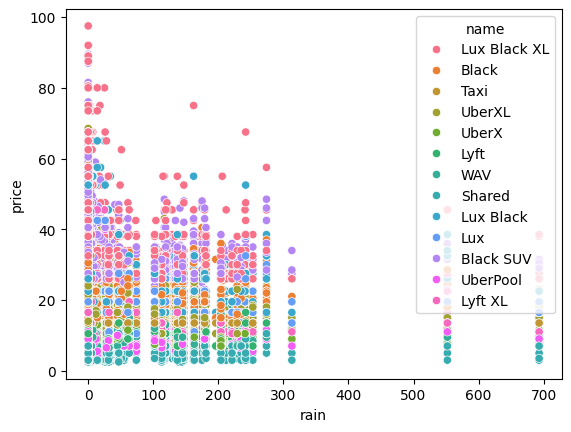

In [34]:
import seaborn as sns
sns.scatterplot(data=df_rides_weather.to_pandas(), x='rain', y='price', hue= 'name')

In [35]:
df_rides_weather.filter(pl.col('name') =='Taxi')

distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,clouds,pressure,rain,humidity,wind
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64
1.57,"""Uber""",2018-11-26 03:40:46.319,"""North End""","""Theatre District""",13.5,1.0,"""9962f244-8fce-4ae9-a583-139d5dвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",41.02,0.87,1014.4,0.0,0.92,1.59
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",13.5,1.0,"""2ee597c2-b685-450e-b3a2-2df42fвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",40.84,0.88,1014.35,0.0,0.93,1.31
1.16,"""Uber""",2018-11-26 03:40:46.421,"""Theatre District""","""Haymarket Square""",13.5,1.0,"""63fbb593-95ba-4b74-88d1-e3eb0dвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",40.8,0.87,1014.39,0.0,0.93,1.55
2.5,"""Uber""",2018-11-26 03:40:46.422,"""Beacon Hill""","""South Station""",13.5,1.0,"""68c01519-3da8-4f84-b113-48cf6dвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",41.02,0.87,1014.39,0.0,0.92,1.5
2.66,"""Uber""",2018-11-26 03:40:46.507,"""Fenway""","""Theatre District""",13.5,1.0,"""6efc3adf-ed3b-4301-8a17-057170вЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",40.84,0.88,1014.35,0.0,0.93,1.31
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1.16,"""Uber""",2018-12-18 19:15:09.247,"""Theatre District""","""Haymarket Square""",13.5,1.0,"""e8558420-b571-4331-9a8b-7e45faвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",null,null,null,0.0,null,null
1.5,"""Uber""",2018-12-18 19:15:10.603,"""Back Bay""","""Fenway""",13.5,1.0,"""eff602f0-ff8e-4ef1-b320-ae4027вЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",null,null,null,0.0,null,null
2.66,"""Uber""",2018-12-18 19:15:10.762,"""Fenway""","""Theatre District""",13.5,1.0,"""a81fbe76-147d-4116-ac41-0d197eвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",null,null,null,0.0,null,null


C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_15604\1755399749.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rides_weather.filter(pl.col('name') =='Lux Black'), x="price", palette='pastel')


<Axes: xlabel='price'>

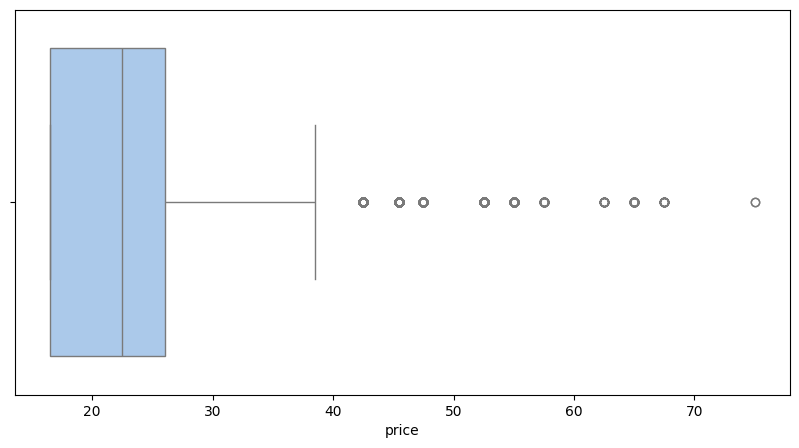

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,5))
sns.boxplot(data=df_rides_weather.filter(pl.col('name') =='Lux Black'), x="price", palette='pastel')

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_15604\2666601864.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rides_weather, x="name", y="price", palette='pastel')


<Axes: xlabel='name', ylabel='price'>

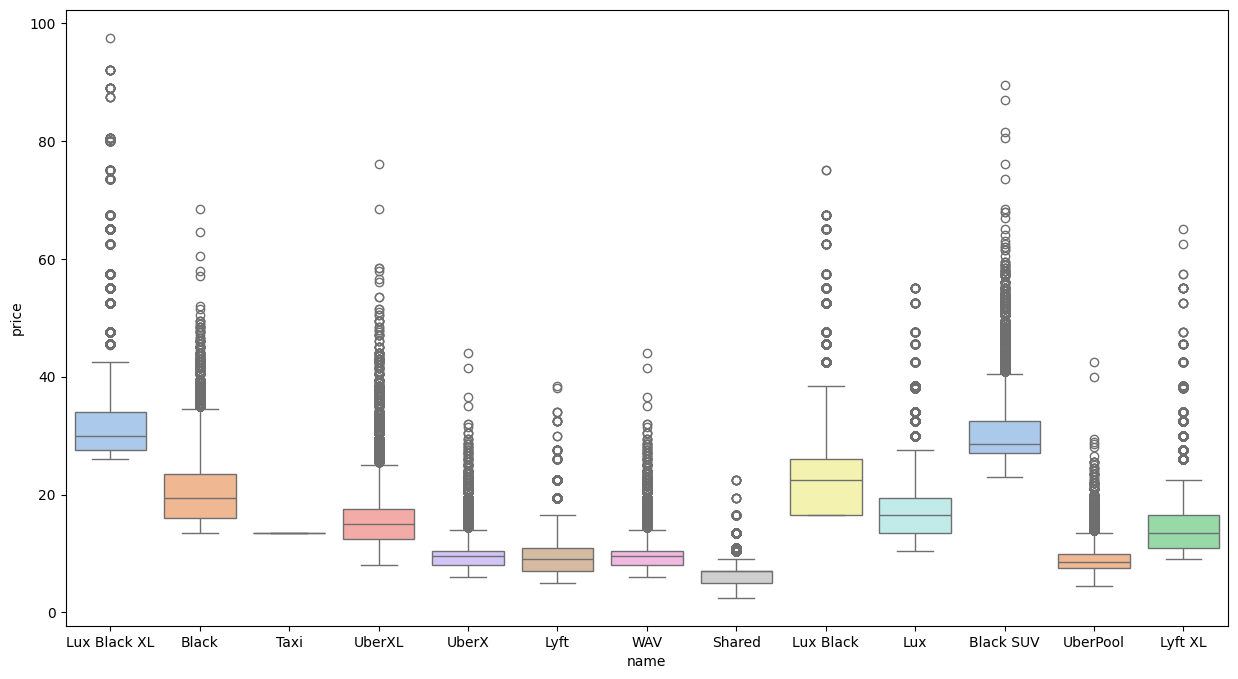

In [37]:
plt.figure(figsize = (15,8))
sns.boxplot(data=df_rides_weather, x="name", y="price", palette='pastel')

distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,clouds,pressure,rain,humidity,wind,hour
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,i8
3.03,"""Lyft""",2018-11-26 03:40:46.318,"""Theatre District""","""Boston University""",34.0,1.0,"""ef4771c2-c88d-4730-aaf7-a95751вЂ¦","""lyft_luxsuv""","""Lux Black XL""",40.8,0.87,1014.39,0.0,0.93,1.55,3
1.3,"""Uber""",2018-11-26 03:40:46.319,"""Theatre District""","""South Station""",18.5,1.0,"""00ea74ea-2c49-416c-bfc5-f78770вЂ¦","""6c84fd89-3f11-4782-9b50-97c468вЂ¦","""Black""",40.8,0.87,1014.39,0.0,0.93,1.55,3
1.57,"""Uber""",2018-11-26 03:40:46.319,"""North End""","""Theatre District""",13.5,1.0,"""9962f244-8fce-4ae9-a583-139d5dвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",41.02,0.87,1014.4,0.0,0.92,1.59,3
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",13.5,1.0,"""2ee597c2-b685-450e-b3a2-2df42fвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",40.84,0.88,1014.35,0.0,0.93,1.31,3
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",32.0,1.0,"""6172077a-22de-481b-aae2-b5763cвЂ¦","""6f72dfc5-27f1-42e8-84db-ccc7a7вЂ¦","""UberXL""",40.84,0.88,1014.35,0.0,0.93,1.31,3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",16.5,1.0,"""11379a6c-1477-4501-ab22-d3a216вЂ¦","""lyft_premier""","""Lux""",null,null,null,0.0,null,null,19
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",10.5,1.0,"""12b81ef2-422b-4a39-9ef7-701c0fвЂ¦","""lyft""","""Lyft""",null,null,null,0.0,null,null,19
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",7.0,1.0,"""24712695-5b52-4886-955f-39c4bcвЂ¦","""lyft_line""","""Shared""",null,null,null,0.0,null,null,19


<Axes: xlabel='hour', ylabel='price'>

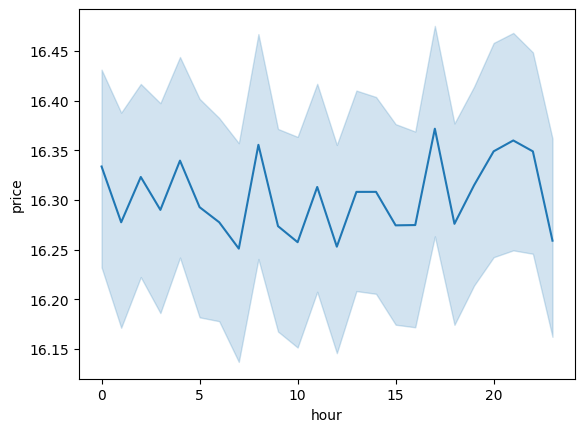

In [38]:
df_rides_weather = df_rides_weather.with_columns(
    pl.col('time_stamp').dt.hour().alias('hour')
)
display(df_rides_weather)
sns.lineplot(data=df_rides_weather.to_pandas(), x='hour', y='price')

### <font color='teal'>Задача №5</font>
Условные выражения и фильтры
- Отфильтруйте поездки по следующим условиям: price > 50 или surge_multiplier > 2
- Добавьте колонку expensive_flag = True, если цена > 40 и surge > 1.5


In [39]:
df_rides_50 = df_rides_weather.filter((pl.col('price') > 50) | (pl.col('surge_multiplier') > 2))
display(df_rides_50)
df_rides_50['name'].unique()

distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,clouds,pressure,rain,humidity,wind,hour
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,i8
4.46,"""Lyft""",2018-11-26 03:40:46.359,"""Financial District""","""Boston University""",62.5,1.75,"""1178f52c-9bd4-4b28-a03a-d94e68вЂ¦","""lyft_lux""","""Lux Black""",40.95,0.89,1014.35,0.0,0.93,1.49,3
4.55,"""Lyft""",2018-11-26 04:43:18.281,"""Fenway""","""Financial District""",62.5,1.5,"""b0674142-317c-4550-b9a2-d9a2feвЂ¦","""lyft_luxsuv""","""Lux Black XL""",40.33,0.85,1014.16,0.0,0.94,2.66,4
3.42,"""Lyft""",2018-11-26 05:14:01.978,"""Northeastern University""","""Financial District""",52.5,1.5,"""bc0639b7-be38-46e0-ba8c-e8835aвЂ¦","""lyft_luxsuv""","""Lux Black XL""",40.46,0.92,1013.75,0.0,0.93,3.06,5
3.17,"""Lyft""",2018-11-26 05:50:01.091,"""Financial District""","""Northeastern University""",73.5,1.75,"""d3cae7d6-461c-4281-808e-53a890вЂ¦","""lyft_luxsuv""","""Lux Black XL""",40.45,1.0,1014.16,0.0,0.91,0.77,5
3.17,"""Lyft""",2018-11-26 05:50:01.091,"""Financial District""","""Northeastern University""",52.5,1.75,"""f9196939-221a-48bf-bb15-f0203cвЂ¦","""lyft_lux""","""Lux Black""",40.45,1.0,1014.16,0.0,0.91,0.77,5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3.44,"""Lyft""",2018-12-18 18:40:04.190,"""North Station""","""Boston University""",55.0,1.5,"""02dac4b0-22b9-4d27-8c39-d3c8b8вЂ¦","""lyft_luxsuv""","""Lux Black XL""",null,null,null,0.0,null,null,18
3.25,"""Lyft""",2018-12-18 18:45:10.460,"""Northeastern University""","""North Station""",52.5,1.25,"""bb190a53-7af7-499d-92ca-718b5cвЂ¦","""lyft_luxsuv""","""Lux Black XL""",30.91,0.0,1012.34,0.0,0.46,13.06,18
2.59,"""Lyft""",2018-12-18 18:45:14,"""North End""","""Back Bay""",73.5,2.0,"""60c59f1d-0448-4890-ac7d-087a97вЂ¦","""lyft_luxsuv""","""Lux Black XL""",30.85,0.0,1012.31,0.0,0.46,13.14,18


name
str
"""Lyft XL"""
"""Black"""
"""Lyft"""
"""Black SUV"""
"""Lux Black XL"""
"""Lux"""
"""Lux Black"""
"""UberXL"""


In [43]:
df_rides_weather = df_rides_weather.with_columns([
    pl.when((pl.col('price') > 40) & (pl.col('surge_multiplier') > 1.5))
    .then(pl.lit(True))
    .otherwise(False).alias('expensive_flag')
])
display(df_rides_weather)

distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,clouds,pressure,rain,humidity,wind,hour,expensive_flag,bad_weather_flag
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,i8,bool,bool
3.03,"""Lyft""",2018-11-26 03:40:46.318,"""Theatre District""","""Boston University""",34.0,1.0,"""ef4771c2-c88d-4730-aaf7-a95751вЂ¦","""lyft_luxsuv""","""Lux Black XL""",40.8,0.87,1014.39,0.0,0.93,1.55,3,false,false
1.3,"""Uber""",2018-11-26 03:40:46.319,"""Theatre District""","""South Station""",18.5,1.0,"""00ea74ea-2c49-416c-bfc5-f78770вЂ¦","""6c84fd89-3f11-4782-9b50-97c468вЂ¦","""Black""",40.8,0.87,1014.39,0.0,0.93,1.55,3,false,false
1.57,"""Uber""",2018-11-26 03:40:46.319,"""North End""","""Theatre District""",13.5,1.0,"""9962f244-8fce-4ae9-a583-139d5dвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",41.02,0.87,1014.4,0.0,0.92,1.59,3,false,false
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",13.5,1.0,"""2ee597c2-b685-450e-b3a2-2df42fвЂ¦","""8cf7e821-f0d3-49c6-8eba-e679c0вЂ¦","""Taxi""",40.84,0.88,1014.35,0.0,0.93,1.31,3,false,false
2.71,"""Uber""",2018-11-26 03:40:46.320,"""Fenway""","""Theatre District""",32.0,1.0,"""6172077a-22de-481b-aae2-b5763cвЂ¦","""6f72dfc5-27f1-42e8-84db-ccc7a7вЂ¦","""UberXL""",40.84,0.88,1014.35,0.0,0.93,1.31,3,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",16.5,1.0,"""11379a6c-1477-4501-ab22-d3a216вЂ¦","""lyft_premier""","""Lux""",null,null,null,0.0,null,null,19,false,false
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",10.5,1.0,"""12b81ef2-422b-4a39-9ef7-701c0fвЂ¦","""lyft""","""Lyft""",null,null,null,0.0,null,null,19,false,false
2.4,"""Lyft""",2018-12-18 19:15:10.943,"""Beacon Hill""","""Northeastern University""",7.0,1.0,"""24712695-5b52-4886-955f-39c4bcвЂ¦","""lyft_line""","""Shared""",null,null,null,0.0,null,null,19,false,false


In [41]:
# - Добавьте колонку bad_weather_flag = True, если rain > 0 или temperature < 0.
df_rides_weather = df_rides_weather.with_columns([
    pl.when((pl.col('rain') > 0) & (pl.col('temp') < 0))
    .then(pl.lit(True))
    .otherwise(False).alias('bad_weather_flag')
])
df_rides_weather.filter((pl.col('rain') > 0) & (pl.col('temp') < 0))


distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,clouds,pressure,rain,humidity,wind,hour,expensive_flag,bad_weather_flag
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,i8,bool,bool


### <font color='teal'>Задача №6</font>
Группировки и агрегаты
- Вычислите среднее значение цены в зависимости от категории такси
- Выведите топ-3 самых дорогих категории для Uber и для Lyft

In [71]:
df_rides_mean = df_rides_weather.group_by('name', 'cab_type').agg(pl.col('price').mean()).sort('price', descending=True)
display(df_rides_mean.with_columns([
    pl.col('price').rank('dense')
    .over('cab_type')
    .alias('top_price')
]).filter(pl.col('top_price') <= 3).sort('cab_type')
)
# x.with_columns([
#     pl.col("price").rank('dense')
#     .over("cab_type")
#     .alias("category")
# ]).filter(pl.col("category") <=3)


df_rides_uber = df_rides_mean.filter(pl.col('cab_type') == 'Uber').sort('price', descending=True).head(3)
display(df_rides_uber)
df_rides_lyft = df_rides_mean.filter(pl.col('cab_type') == 'Lyft').sort('price', descending=True).head(3)
display(df_rides_lyft)

display(df_rides_mean)

name,cab_type,price,top_price
str,str,f64,u32
"""Lyft XL""","""Lyft""",15.309363,3
"""Lyft""","""Lyft""",9.610885,2
"""Shared""","""Lyft""",6.029893,1
"""UberX""","""Uber""",9.765074,3
"""WAV""","""Uber""",9.765019,2
"""UberPool""","""Uber""",8.7525,1


name,cab_type,price
str,str,f64
"""Black SUV""","""Uber""",30.286763
"""Black""","""Uber""",20.523786
"""UberXL""","""Uber""",15.678144


name,cab_type,price
str,str,f64
"""Lux Black XL""","""Lyft""",32.324086
"""Lux Black""","""Lyft""",23.062468
"""Lux""","""Lyft""",17.77124


name,cab_type,price
str,str,f64
"""Lux Black XL""","""Lyft""",32.324086
"""Black SUV""","""Uber""",30.286763
"""Lux Black""","""Lyft""",23.062468
"""Black""","""Uber""",20.523786
"""Lux""","""Lyft""",17.77124
…,…,…
"""UberX""","""Uber""",9.765074
"""WAV""","""Uber""",9.765019
"""Lyft""","""Lyft""",9.610885


### <font color='teal'>Задача №7</font>
Оконные функции
- Для каждого source вычислить отклонение цены от средней по source.

In [77]:
display(df_rides.with_columns([
    (pl.col('price') - pl.col('price').mean())
    .over('source')
    .alias('otk')
]).filter(pl.col('source') == 'Boston University'))

display(df_rides.group_by('source').agg(pl.col('price').mean()))

distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,mean_price_name,otk
f64,str,datetime[Ојs],str,str,f64,f64,str,str,str,f64,f64
3.03,"""Lyft""",2018-11-26 03:40:46.318,"""Theatre District""","""Boston University""",34.0,1.0,"""ef4771c2-c88d-4730-aaf7-a95751вЂ¦","""lyft_luxsuv""","""Lux Black XL""",32.324086,15.572511
4.46,"""Lyft""",2018-11-26 03:40:46.359,"""Financial District""","""Boston University""",62.5,1.75,"""1178f52c-9bd4-4b28-a03a-d94e68вЂ¦","""lyft_lux""","""Lux Black""",23.062468,44.072511
4.46,"""Lyft""",2018-11-26 03:40:46.359,"""Financial District""","""Boston University""",47.5,1.75,"""3b5af7f6-40ba-42f2-a218-971dcbвЂ¦","""lyft_premier""","""Lux""",17.77124,29.072511
3.06,"""Lyft""",2018-11-26 03:40:46.551,"""West End""","""Boston University""",27.5,1.0,"""37930372-f1f8-4986-b938-073c96вЂ¦","""lyft_lux""","""Lux Black""",23.062468,9.072511
3.06,"""Lyft""",2018-11-26 03:40:46.551,"""West End""","""Boston University""",10.5,1.0,"""5f3ee457-8e98-4b4b-9582-e6bc3aвЂ¦","""lyft""","""Lyft""",9.610885,-7.927489
…,…,…,…,…,…,…,…,…,…,…,…
4.72,"""Uber""",2018-12-18 19:15:06.188,"""Financial District""","""Boston University""",40.5,1.0,"""ba822342-1fef-4bf9-abf6-117f94вЂ¦","""6d318bcc-22a3-4af6-bddd-b409bfвЂ¦","""Black SUV""",30.286763,22.072511
4.72,"""Uber""",2018-12-18 19:15:06.188,"""Financial District""","""Boston University""",14.0,1.0,"""c3fe6cf8-41cf-4325-b2aa-b35af5вЂ¦","""55c66225-fbe7-4fd5-9072-eab1ecвЂ¦","""UberX""",9.765074,-4.427489
4.72,"""Uber""",2018-12-18 19:15:06.188,"""Financial District""","""Boston University""",32.0,1.0,"""e0565487-9754-4946-a95f-efa200вЂ¦","""6c84fd89-3f11-4782-9b50-97c468вЂ¦","""Black""",20.523786,13.572511


source,price
str,f64
"""Boston University""",18.427489
"""Theatre District""",16.349933
"""Beacon Hill""",15.492047
"""Fenway""",17.991629
"""Back Bay""",15.845029
…,…
"""South Station""",15.49981
"""Haymarket Square""",13.571905
"""Financial District""",17.810724


### <font color='teal'>Задача №8</font>
Визуализация
- Столбчатая диаграмма по количеству поездок в Uber/Lyft
- Распределение цены
- Зависимость цены и времени, разделенные по дате *

In [82]:
df_rides_count = df_rides.group_by('cab_type').agg(pl.len().alias('count')).sort('count', descending=True)
display(df_rides_count)

cab_type,count
str,u32
"""Uber""",385663
"""Lyft""",307408


C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_15604\3746428737.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rides_count , x='cab_type', y='count', palette='pastel')


<Axes: xlabel='cab_type', ylabel='count'>

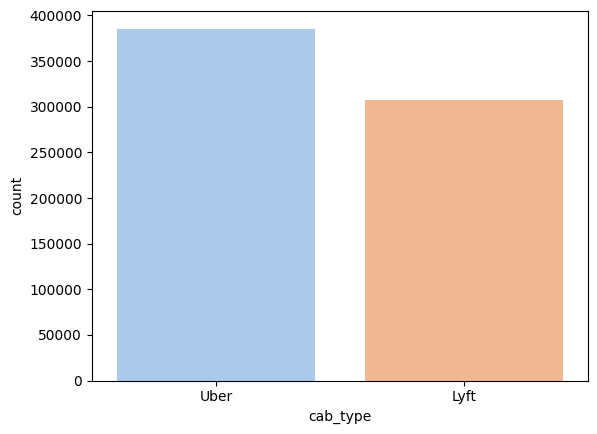

In [85]:
sns.barplot(data=df_rides_count , x='cab_type', y='count', palette='pastel')

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_15604\2472283030.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rides.to_pandas(), x='cab_type', palette='pastel')


<Axes: xlabel='cab_type', ylabel='count'>

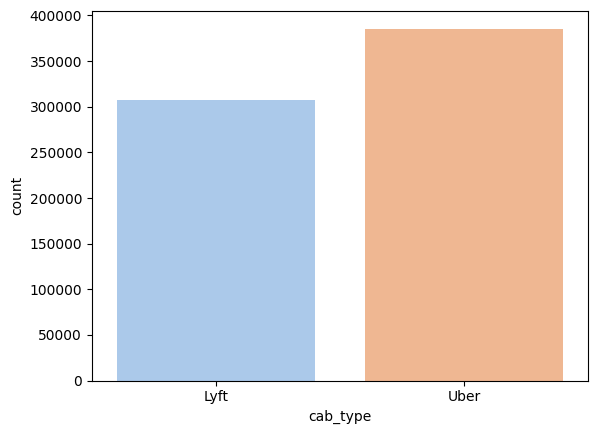

In [86]:
sns.countplot(data=df_rides.to_pandas(), x='cab_type', palette='pastel')

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_15604\2705056096.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_rides_weather.to_pandas(), x='price', palette='pastel', bins=30)


(0.0, 50.0)

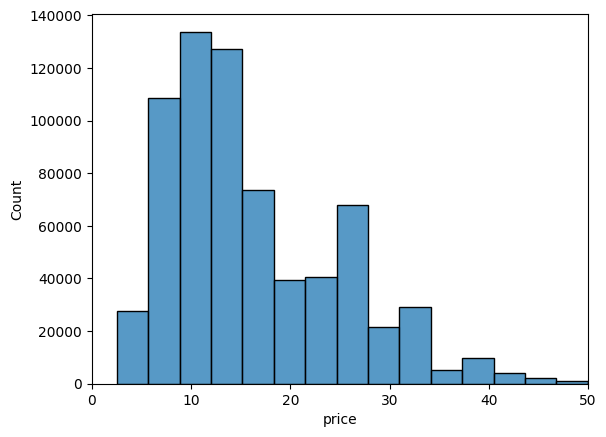

In [91]:
sns.histplot(data=df_rides_weather.to_pandas(), x='price', palette='pastel', bins=30)
plt.xlim(0, 50)